In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")

In [4]:
print("Розмір ratings:", ratings.shape)
print("Розмір movies:", movies.shape)

print(ratings.head())
print(movies.head())

Розмір ratings: (100836, 4)
Розмір movies: (9742, 3)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [5]:
df = ratings.merge(movies, on="movieId")
print("Розмір об'єднаної таблиці:", df.shape)
df.head()

Розмір об'єднаної таблиці: (100836, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [6]:
liked = df[df["rating"] >= 4.0].copy()
print("Розмір таблиці після фільтрації:", liked.shape)

Розмір таблиці після фільтрації: (48580, 6)


In [7]:
print("Кількість унікальних користувачів:", liked["userId"].nunique())
print("Кількість унікальних фільмів:", liked["title"].nunique())

Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6297


In [18]:
transaction_matrix = (
    liked.pivot_table(
        index="userId",
        columns="title",
        values="rating",
        aggfunc="max"
    )
    .notnull()
    .astype(int)
)

print("Розмір транзакційної матриці:", transaction_matrix.shape)
transaction_matrix.head()

Розмір транзакційної матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
transaction_matrix = transaction_matrix.astype(bool)
transaction_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
frequent_005 = apriori(transaction_matrix, min_support=0.05, use_colnames=True)
frequent_01 = apriori(transaction_matrix, min_support=0.1, use_colnames=True)
frequent_03 = apriori(transaction_matrix, min_support=0.3, use_colnames=True)

print("Кількість наборів при 0.05:", len(frequent_005))
print("Кількість наборів при 0.1:", len(frequent_01))
print("Кількість наборів при 0.3:", len(frequent_03))

Кількість наборів при 0.05: 33189
Кількість наборів при 0.1: 863
Кількість наборів при 0.3: 6


In [21]:
frequent_01_sorted = frequent_01.sort_values(by="support", ascending=False)
frequent_01_sorted.head(10)

,support,itemsets
93,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
40,0.408867,frozenset({Forrest Gump (1994)})
83,0.400657,frozenset({Pulp Fiction (1994)})
96,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
68,0.364532,"frozenset({Matrix, The (1999)})"
103,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...
38,0.293924,frozenset({Fight Club (1999)})
90,0.287356,frozenset({Schindler's List (1993)})
279,0.275862,"frozenset({Shawshank Redemption, The (1994), F..."
104,0.275862,frozenset({Star Wars: Episode V - The Empire S...


In [12]:
frequent_01["length"] = frequent_01["itemsets"].apply(len)
frequent_01.sort_values(by=["length", "support"], ascending=[False, False]).head(10)

,support,itemsets,length
851,0.131363,frozenset({Star Wars: Episode IV - A New Hope ...,4
860,0.128079,frozenset({Star Wars: Episode IV - A New Hope ...,4
836,0.123153,"frozenset({Silence of the Lambs, The (1991), S...",4
844,0.123153,frozenset({Lord of the Rings: The Return of th...,4
856,0.116585,"frozenset({Silence of the Lambs, The (1991), S...",4
859,0.114943,frozenset({Star Wars: Episode IV - A New Hope ...,4
848,0.111658,frozenset({Star Wars: Episode IV - A New Hope ...,4
829,0.110016,"frozenset({Fight Club (1999), Silence of the L...",4
833,0.110016,"frozenset({Pulp Fiction (1994), Matrix, The (1...",4
847,0.110016,frozenset({Star Wars: Episode IV - A New Hope ...,4


In [22]:
pairs = frequent_01[frequent_01["itemsets"].apply(len) == 2]
pairs.sort_values(by="support", ascending=False).head(10)

,support,itemsets
279,0.275862,"frozenset({Shawshank Redemption, The (1994), F..."
448,0.259442,"frozenset({Pulp Fiction (1994), Shawshank Rede..."
449,0.249589,"frozenset({Silence of the Lambs, The (1991), P..."
515,0.236453,frozenset({Star Wars: Episode IV - A New Hope ...
495,0.229885,"frozenset({Silence of the Lambs, The (1991), S..."
274,0.223317,"frozenset({Pulp Fiction (1994), Forrest Gump (..."
484,0.211823,"frozenset({Shawshank Redemption, The (1994), S..."
281,0.210181,"frozenset({Silence of the Lambs, The (1991), F..."
411,0.208539,"frozenset({Pulp Fiction (1994), Matrix, The (1..."
516,0.206897,frozenset({Star Wars: Episode IV - A New Hope ...


In [23]:
rules = association_rules(frequent_01, metric="confidence", min_threshold=0.5)

print("Кількість правил:", len(rules))
rules.head()

Кількість правил: 1652


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Aladdin (1992)}),frozenset({Forrest Gump (1994)}),0.185550,0.408867,0.119869,0.646018,1.580019,1.0,0.044003,1.669951,0.450729,0.252595,0.401180,0.469595
1,frozenset({Aladdin (1992)}),frozenset({Jurassic Park (1993)}),0.185550,0.238095,0.105090,0.566372,2.378761,1.0,0.060912,1.757046,0.711662,0.329897,0.430863,0.503875
2,frozenset({Aladdin (1992)}),"frozenset({Lion King, The (1994)})",0.185550,0.188834,0.114943,0.619469,3.280492,1.0,0.079904,2.131668,0.853543,0.443038,0.530884,0.614082
3,"frozenset({Lion King, The (1994)})",frozenset({Aladdin (1992)}),0.188834,0.185550,0.114943,0.608696,3.280492,1.0,0.079904,2.081372,0.856998,0.443038,0.519548,0.614082
4,frozenset({Aladdin (1992)}),frozenset({Pulp Fiction (1994)}),0.185550,0.400657,0.100164,0.539823,1.347345,1.0,0.025822,1.302419,0.316532,0.206081,0.232198,0.394912


In [24]:
top_rules = rules.sort_values(by="lift", ascending=False)
top_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
229,frozenset({Kill Bill: Vol. 1 (2003)}),frozenset({Kill Bill: Vol. 2 (2004)}),0.106732,0.738636,6.247633
230,frozenset({Kill Bill: Vol. 2 (2004)}),frozenset({Kill Bill: Vol. 1 (2003)}),0.106732,0.902778,6.247633
1467,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Indiana Jones and the Last Crusade ...,0.106732,0.613208,4.668042
1463,frozenset({Indiana Jones and the Last Crusade ...,frozenset({Star Wars: Episode V - The Empire S...,0.106732,0.812500,4.668042
757,"frozenset({Goodfellas (1990), Godfather, The (...","frozenset({Godfather: Part II, The (1974)})",0.100164,0.792208,4.508921
761,"frozenset({Godfather: Part II, The (1974)})","frozenset({Goodfellas (1990), Godfather, The (...",0.100164,0.570093,4.508921
1483,"frozenset({Lord of the Rings: The Two Towers, ...",frozenset({Lord of the Rings: The Return of th...,0.123153,0.882353,4.440933
1488,frozenset({Lord of the Rings: The Return of th...,"frozenset({Lord of the Rings: The Two Towers, ...",0.123153,0.619835,4.440933
1343,frozenset({Lord of the Rings: The Return of th...,"frozenset({Fight Club (1999), Lord of the Ring...",0.105090,0.528926,4.412544
1338,"frozenset({Fight Club (1999), Lord of the Ring...",frozenset({Lord of the Rings: The Return of th...,0.105090,0.876712,4.412544


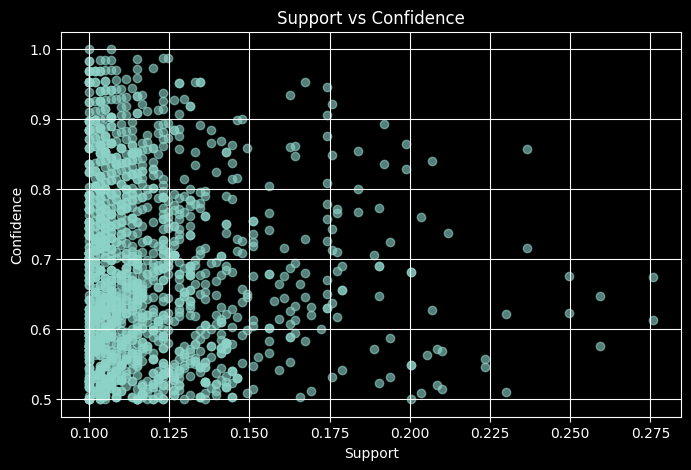

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(rules["support"], rules["confidence"], alpha=0.6)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.grid(True)
plt.show()

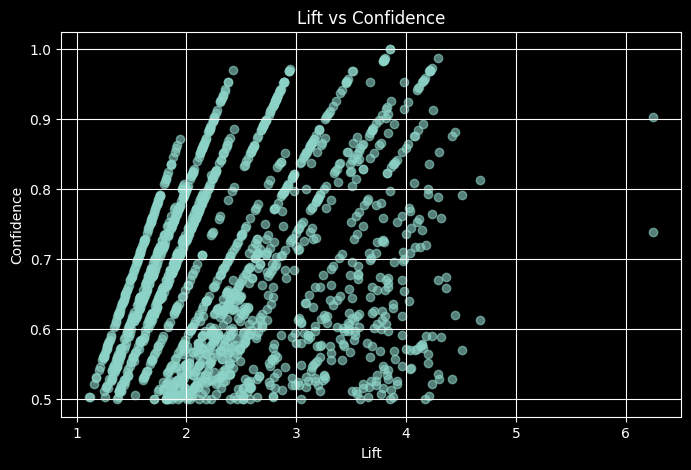

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(rules["lift"], rules["confidence"], alpha=0.6)
plt.xlabel("Lift")
plt.ylabel("Confidence")
plt.title("Lift vs Confidence")
plt.grid(True)
plt.show()